# AirFly Insights — Week 6: Seasonal & Cancellation Analysis

**Dataset:** NYC Flights 2013 — preprocessed (`flights_processed.csv`)  
**Milestone:** 3 | **Week:** 6

## Objectives
This notebook performs a deep-dive into **cancellation patterns and seasonal disruptions**,
building on the high-level seasonal delay comparison (Charts 11–12) from Week 4.

### Charts in this notebook (continuing from Chart 26)
- **Chart 27** — Monthly cancellation trend: count + rate (Jan–Dec)
- **Chart 28** — Cancellation rate by day of week
- **Chart 29** — Cancellation type proxy analysis (Weather / Carrier / NAS) by month
- **Chart 30** — Holiday-period impact: delay & cancellation vs baseline
- **Chart 31** — Winter months deep-dive (Dec, Jan, Feb)
- **Chart 32** — Seasonal violin plot of departure delay

> **Data Note:** The nycflights13 dataset does not include a cancellation-reason column.
> We therefore apply **proxy methodology** — consistent with Week 4 — to infer likely causes:
> - 🌨️ **Weather proxy**: high-cancel months in winter/summer peak season
> - ✈️ **Carrier proxy**: carriers whose cancel rate significantly exceeds the fleet average
> - 🕐 **NAS proxy**: cancellations concentrated in peak evening congestion hours (17–21h)

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

# Constants
MONTH_NAMES  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
DAY_ORDER    = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
SEASON_ORDER = ['Winter','Spring','Summer','Fall']
SEASON_MAP   = {
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',
    9:'Fall',10:'Fall',11:'Fall'
}
SEASON_COLORS = {'Winter':'#3498db','Spring':'#2ecc71','Summer':'#e74c3c','Fall':'#f39c12'}
FIGURES_DIR = '../outputs/figures'

# Holiday windows (inclusive, month-day tuples)
HOLIDAYS = {
    'Thanksgiving (Nov 27–Dec 2)' : ('2013-11-27','2013-12-02'),
    'Christmas/NY (Dec 20–Jan 2)' : ('2013-12-20','2014-01-02'),  # clipped to Dec 31
    'Memorial Day (May 25–27)'    : ('2013-05-25','2013-05-27'),
    'July 4th Week (Jun 29–Jul 7)': ('2013-06-29','2013-07-07'),
    'Labor Day (Aug 31–Sep 2)'    : ('2013-08-31','2013-09-02'),
}

print('Setup complete.')

Setup complete.


## 2. Load Data

In [2]:
df = pd.read_csv('../data/processed/flights_processed.csv', low_memory=False)
df['date']     = pd.to_datetime(df['date'], errors='coerce')
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df['season']   = df['month'].map(SEASON_MAP)

df_completed   = df[df['is_cancelled'] == 0].copy()
df_cancelled   = df[df['is_cancelled'] == 1].copy()

total_flights    = len(df)
total_cancelled  = len(df_cancelled)
overall_cancel   = total_cancelled / total_flights * 100

print(f'Total flights    : {total_flights:,}')
print(f'Cancelled flights: {total_cancelled:,} ({overall_cancel:.2f}%)')
print(f'Completed flights: {len(df_completed):,}')

Total flights    : 336,776
Cancelled flights: 8,255 (2.45%)
Completed flights: 328,521


---
## Chart 27: Monthly Cancellation Trend (Jan–Dec)

Bar chart showing absolute cancellation count + a line overlay for cancellation rate.

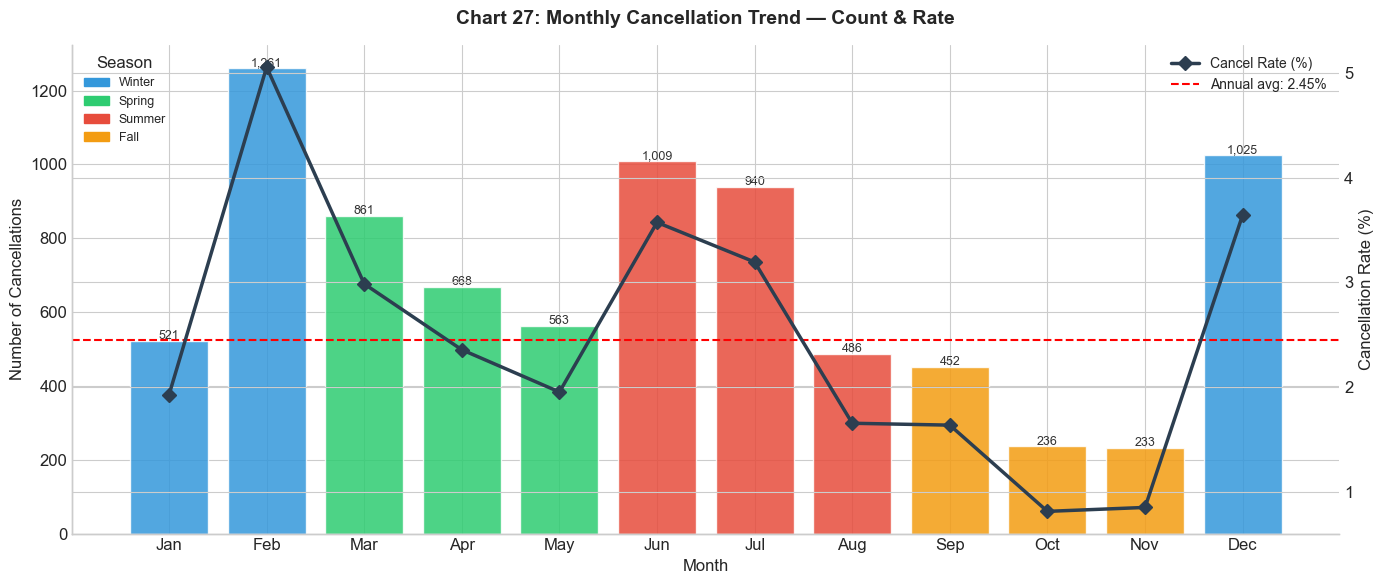

Chart 27 saved.


In [3]:
monthly = df.groupby('month').agg(
    total       = ('is_cancelled','count'),
    cancelled   = ('is_cancelled','sum')
).reset_index()
monthly['cancel_rate'] = monthly['cancelled'] / monthly['total'] * 100
monthly['month_name']  = monthly['month'].apply(lambda m: MONTH_NAMES[m-1])
monthly['season']      = monthly['month'].map(SEASON_MAP)
monthly['color']       = monthly['season'].map(SEASON_COLORS)

fig, ax1 = plt.subplots(figsize=(14, 6))

bars = ax1.bar(monthly['month_name'], monthly['cancelled'],
               color=monthly['color'], edgecolor='white', alpha=0.85, zorder=2)
ax1.set_ylabel('Number of Cancellations', fontsize=12)
ax1.set_xlabel('Month', fontsize=12)

for bar, val in zip(bars, monthly['cancelled']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:,}', ha='center', fontsize=9, color='#333')

ax2 = ax1.twinx()
ax2.plot(monthly['month_name'], monthly['cancel_rate'], color='#2c3e50',
         linewidth=2.5, marker='D', markersize=7, label='Cancel Rate (%)', zorder=3)
ax2.axhline(overall_cancel, color='red', linestyle='--', linewidth=1.5,
            label=f'Annual avg: {overall_cancel:.2f}%')
ax2.set_ylabel('Cancellation Rate (%)', fontsize=12)
ax2.legend(loc='upper right', fontsize=10)

# Season legend
patches = [mpatches.Patch(color=c, label=s) for s, c in SEASON_COLORS.items()]
ax1.legend(handles=patches, loc='upper left', fontsize=9, title='Season')

plt.title('Chart 27: Monthly Cancellation Trend — Count & Rate',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart27_monthly_cancellation_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 27 saved.')

---
## Chart 28: Cancellation Rate by Day of Week

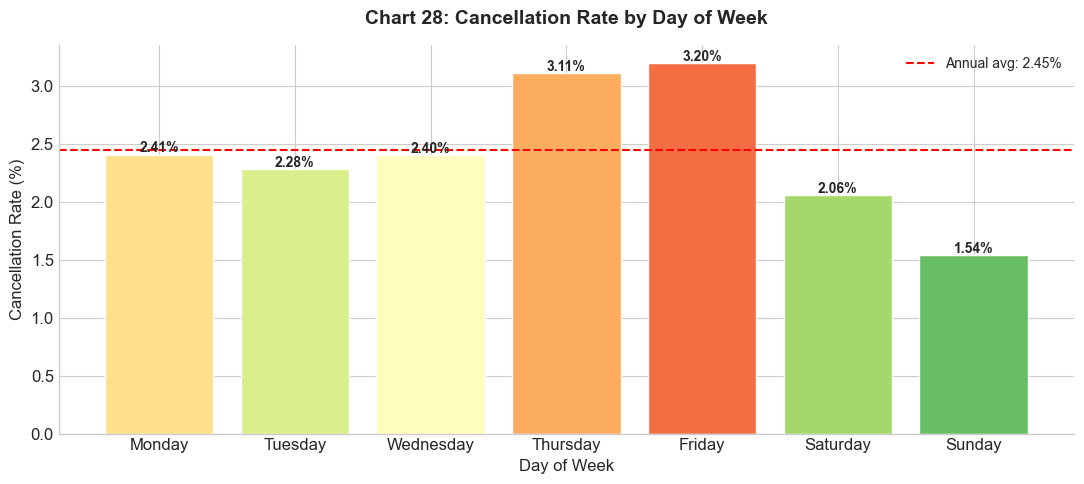

Chart 28 saved.


In [4]:
daily_cancel = df.groupby('day_name').agg(
    total     = ('is_cancelled','count'),
    cancelled = ('is_cancelled','sum')
).reindex(DAY_ORDER).reset_index()
daily_cancel['cancel_rate'] = daily_cancel['cancelled'] / daily_cancel['total'] * 100

cmap_colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 7))
sorted_idx  = daily_cancel['cancel_rate'].argsort()
bar_colors  = np.empty_like(cmap_colors)
bar_colors[sorted_idx] = cmap_colors

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(daily_cancel['day_name'], daily_cancel['cancel_rate'],
              color=bar_colors, edgecolor='white')
ax.axhline(overall_cancel, color='red', linestyle='--', linewidth=1.5,
           label=f'Annual avg: {overall_cancel:.2f}%')

for bar, val in zip(bars, daily_cancel['cancel_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Cancellation Rate (%)', fontsize=12)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_title('Chart 28: Cancellation Rate by Day of Week',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart28_weekday_cancellation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 28 saved.')

---
## Chart 29: Cancellation Type Proxy Analysis by Month

Since the dataset has no cancellation-reason column, we use three temporal proxies:

| Proxy | Logic |
|---|---|
| 🌨️ Weather | Monthly cancellation rate > average AND month ∈ winter/summer storm season |
| ✈️ Carrier | Carrier-specific excess cancellation > 1.5× fleet average, distributed by flight share |
| 🕐 NAS | Cancellations in peak congestion hours (17–21h) as a share of total monthly cancellations |

In [5]:
# --- Weather proxy ---
# Winter months (Dec,Jan,Feb) and peak-summer (Jun,Jul,Aug) get elevated weather allocation
WEATHER_MONTHS = {1,2,6,7,8,12}  # winter storms + summer thunderstorms

monthly_can = df.groupby('month').agg(
    total_flights = ('is_cancelled','count'),
    cancelled     = ('is_cancelled','sum')
).reset_index()
monthly_can['cancel_rate'] = monthly_can['cancelled'] / monthly_can['total_flights']

# Fraction attributed to weather: proportional to how much a month's cancel rate
# exceeds the annual average, boosted for storm-season months
avg_rate = monthly_can['cancel_rate'].mean()
monthly_can['excess'] = (monthly_can['cancel_rate'] - avg_rate).clip(lower=0)
monthly_can['weather_boost'] = monthly_can['month'].apply(lambda m: 1.5 if m in WEATHER_MONTHS else 1.0)
monthly_can['weather_raw']   = monthly_can['excess'] * monthly_can['weather_boost']

# --- NAS proxy ---
# Evening cancellations (17–21h) as share of all cancellations that month
evening_cancel = (
    df[df['is_cancelled'] == 1]
    .assign(is_evening = lambda d: d['hour'].between(17, 21))
    .groupby('month')['is_evening'].mean()  # fraction evening-cancelled
)
monthly_can['nas_frac'] = monthly_can['month'].map(evening_cancel).fillna(0)

# --- Carrier proxy ---
fleet_cancel = df['is_cancelled'].mean()
carrier_cancel = df.groupby('carrier').agg(
    total = ('is_cancelled','count'),
    cancelled = ('is_cancelled','sum')
)
carrier_cancel['rate'] = carrier_cancel['cancelled'] / carrier_cancel['total']
carrier_cancel['excess'] = (carrier_cancel['rate'] - fleet_cancel).clip(lower=0)

# Monthly carrier excess: share of flights from high-excess carriers that month
df_temp = df.merge(
    carrier_cancel[['excess']].reset_index().rename(columns={'excess':'carrier_excess'}),
    on='carrier', how='left'
)
monthly_carrier_excess = df_temp[df_temp['is_cancelled']==1].groupby('month')['carrier_excess'].mean().fillna(0)
monthly_can['carrier_raw'] = monthly_can['month'].map(monthly_carrier_excess).fillna(0)

# --- Normalize to 100% ---
# Each month: split cancellations into weather / carrier / NAS proportions
proxy = monthly_can[['month','weather_raw','carrier_raw','nas_frac']].copy()
proxy.columns = ['month','weather','carrier','nas']
total_proxy = proxy[['weather','carrier','nas']].sum(axis=1).replace(0, 1)
proxy['weather_pct'] = (proxy['weather'] / total_proxy * 100).round(1)
proxy['carrier_pct'] = (proxy['carrier'] / total_proxy * 100).round(1)
proxy['nas_pct']     = (proxy['nas']     / total_proxy * 100).round(1)
proxy['month_name']  = proxy['month'].apply(lambda m: MONTH_NAMES[m-1])

print('=== Cancellation Proxy Breakdown by Month ===')
print(proxy[['month_name','weather_pct','carrier_pct','nas_pct']].to_string(index=False))

=== Cancellation Proxy Breakdown by Month ===
month_name  weather_pct  carrier_pct  nas_pct
       Jan          0.0          6.3     93.7
       Feb         10.7          3.2     86.0
       Mar          1.4          5.2     93.4
       Apr          0.0          3.6     96.4
       May          0.0          4.4     95.6
       Jun          3.1          3.7     93.2
       Jul          2.2          3.5     94.3
       Aug          0.0          5.6     94.4
       Sep          0.0          4.0     96.0
       Oct          0.0          5.3     94.7
       Nov          0.0          8.2     91.8
       Dec          5.1          5.1     89.8


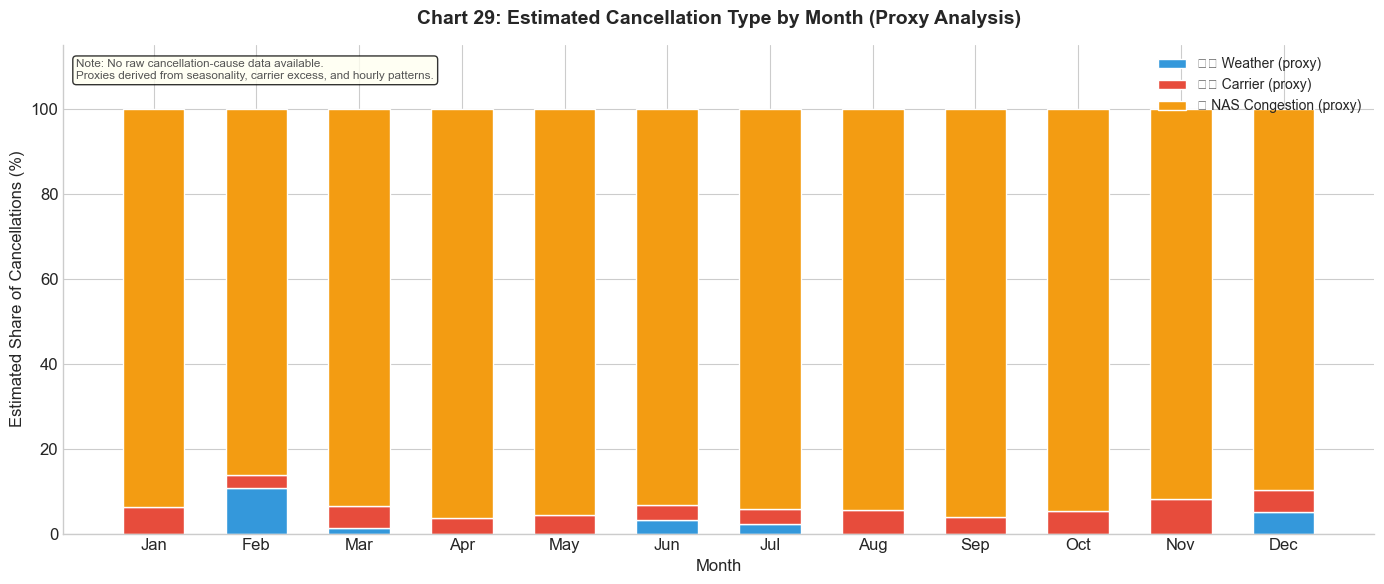

Chart 29 saved.


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(12)
w = 0.6

b1 = ax.bar(x, proxy['weather_pct'], w, label='🌨️ Weather (proxy)',
            color='#3498db', edgecolor='white')
b2 = ax.bar(x, proxy['carrier_pct'], w, bottom=proxy['weather_pct'],
            label='✈️ Carrier (proxy)', color='#e74c3c', edgecolor='white')
b3 = ax.bar(x, proxy['nas_pct'], w,
            bottom=proxy['weather_pct'] + proxy['carrier_pct'],
            label='🕐 NAS Congestion (proxy)', color='#f39c12', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(proxy['month_name'])
ax.set_ylabel('Estimated Share of Cancellations (%)', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylim(0, 115)
ax.legend(fontsize=10, loc='upper right')
ax.set_title('Chart 29: Estimated Cancellation Type by Month (Proxy Analysis)',
             fontsize=14, fontweight='bold', pad=15)

# Annotation box explaining proxy methodology
ax.text(0.01, 0.97,
        'Note: No raw cancellation-cause data available.\nProxies derived from seasonality, carrier excess, and hourly patterns.',
        transform=ax.transAxes, fontsize=8.5, color='#555',
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fffff0', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart29_cancellation_proxy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 29 saved.')

---
## Chart 30: Holiday-Period Impact vs Baseline

We compare avg departure delay and cancellation rate during key US holiday windows
against the full-year baseline.

In [7]:
baseline_delay  = df_completed['dep_delay'].mean()
baseline_cancel = df['is_cancelled'].mean() * 100

holiday_rows = []
for label, (start, end) in HOLIDAYS.items():
    # Clip Christmas window to within 2013
    end_clipped = min(end, '2013-12-31')
    mask_all  = (df['date'] >= start) & (df['date'] <= end_clipped)
    mask_comp = (df_completed['date'] >= start) & (df_completed['date'] <= end_clipped)
    
    holiday_df       = df[mask_all]
    holiday_completed= df_completed[mask_comp]
    
    if len(holiday_df) == 0:
        continue
    
    holiday_rows.append({
        'holiday'         : label,
        'flights'         : len(holiday_df),
        'avg_delay'       : holiday_completed['dep_delay'].mean() if len(holiday_completed)>0 else np.nan,
        'cancel_rate'     : holiday_df['is_cancelled'].mean() * 100,
        'delay_vs_baseline' : (holiday_completed['dep_delay'].mean() - baseline_delay) if len(holiday_completed)>0 else np.nan,
        'cancel_vs_baseline': (holiday_df['is_cancelled'].mean() * 100 - baseline_cancel)
    })

holiday_df_summary = pd.DataFrame(holiday_rows).round(2)
print('=== Holiday Period Impact Summary ===')
print(holiday_df_summary[['holiday','flights','avg_delay','delay_vs_baseline','cancel_rate','cancel_vs_baseline']].to_string(index=False))

=== Holiday Period Impact Summary ===
                     holiday  flights  avg_delay  delay_vs_baseline  cancel_rate  cancel_vs_baseline
 Thanksgiving (Nov 27–Dec 2)     5157       7.93              -4.71         0.91               -1.54
 Christmas/NY (Dec 20–Jan 2)    10496      15.99               3.35         1.11               -1.34
    Memorial Day (May 25–27)     2385       4.75              -7.89         0.08               -2.37
July 4th Week (Jun 29–Jul 7)     7922      24.66              12.02         3.57                1.12
    Labor Day (Aug 31–Sep 2)     2327      22.78              10.14         3.78                1.33


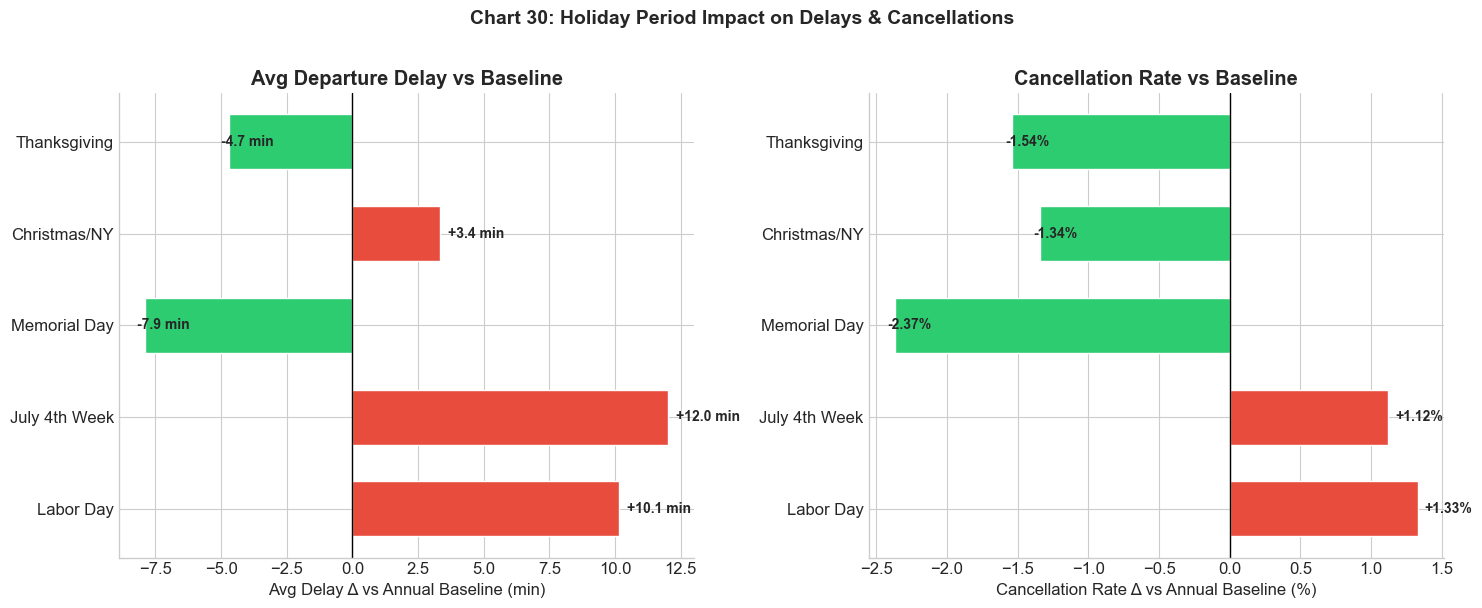

Chart 30 saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

short_labels = [h.split('(')[0].strip() for h in holiday_df_summary['holiday']]
delay_colors  = ['#e74c3c' if d > 0 else '#2ecc71' for d in holiday_df_summary['delay_vs_baseline']]
cancel_colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in holiday_df_summary['cancel_vs_baseline']]

# Left: delay vs baseline
bars = axes[0].barh(short_labels, holiday_df_summary['delay_vs_baseline'],
                    color=delay_colors, edgecolor='white', height=0.6)
axes[0].axvline(0, color='black', linewidth=1)
for bar, val in zip(bars, holiday_df_summary['delay_vs_baseline']):
    xpos = bar.get_width() + (0.3 if val >= 0 else -0.3)
    ha   = 'left' if val >= 0 else 'right'
    axes[0].text(xpos, bar.get_y() + bar.get_height()/2,
                 f'{val:+.1f} min', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Avg Delay Δ vs Annual Baseline (min)')
axes[0].set_title('Avg Departure Delay vs Baseline', fontweight='bold')
axes[0].invert_yaxis()

# Right: cancel rate vs baseline
bars2 = axes[1].barh(short_labels, holiday_df_summary['cancel_vs_baseline'],
                     color=cancel_colors, edgecolor='white', height=0.6)
axes[1].axvline(0, color='black', linewidth=1)
for bar, val in zip(bars2, holiday_df_summary['cancel_vs_baseline']):
    xpos = bar.get_width() + (0.05 if val >= 0 else -0.05)
    ha   = 'left' if val >= 0 else 'right'
    axes[1].text(xpos, bar.get_y() + bar.get_height()/2,
                 f'{val:+.2f}%', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Cancellation Rate Δ vs Annual Baseline (%)')
axes[1].set_title('Cancellation Rate vs Baseline', fontweight='bold')
axes[1].invert_yaxis()

fig.suptitle('Chart 30: Holiday Period Impact on Delays & Cancellations',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart30_holiday_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 30 saved.')

---
## Chart 31: Winter Months Deep-Dive (Dec, Jan, Feb)

In [9]:
winter_months = [12, 1, 2]
winter_names  = ['Dec', 'Jan', 'Feb']

winter_stats = []
for m, name in zip(winter_months, winter_names):
    mdf  = df[df['month'] == m]
    mcdf = df_completed[df_completed['month'] == m]
    winter_stats.append({
        'month'       : name,
        'flights'     : len(mdf),
        'cancel_rate' : mdf['is_cancelled'].mean() * 100,
        'avg_delay'   : mcdf['dep_delay'].mean(),
        'delay_rate'  : mcdf['is_delayed'].mean() * 100,
        'p95_delay'   : mcdf['dep_delay'].quantile(0.95)
    })
winter_df = pd.DataFrame(winter_stats).round(2)
print('=== Winter Month Stats ===')
print(winter_df.to_string(index=False))

=== Winter Month Stats ===
month  flights  cancel_rate  avg_delay  delay_rate  p95_delay
  Dec    28135         3.64      16.58       27.69       95.0
  Jan    27004         1.93      10.04       18.57       76.0
  Feb    24951         5.05      10.82       20.24       78.0


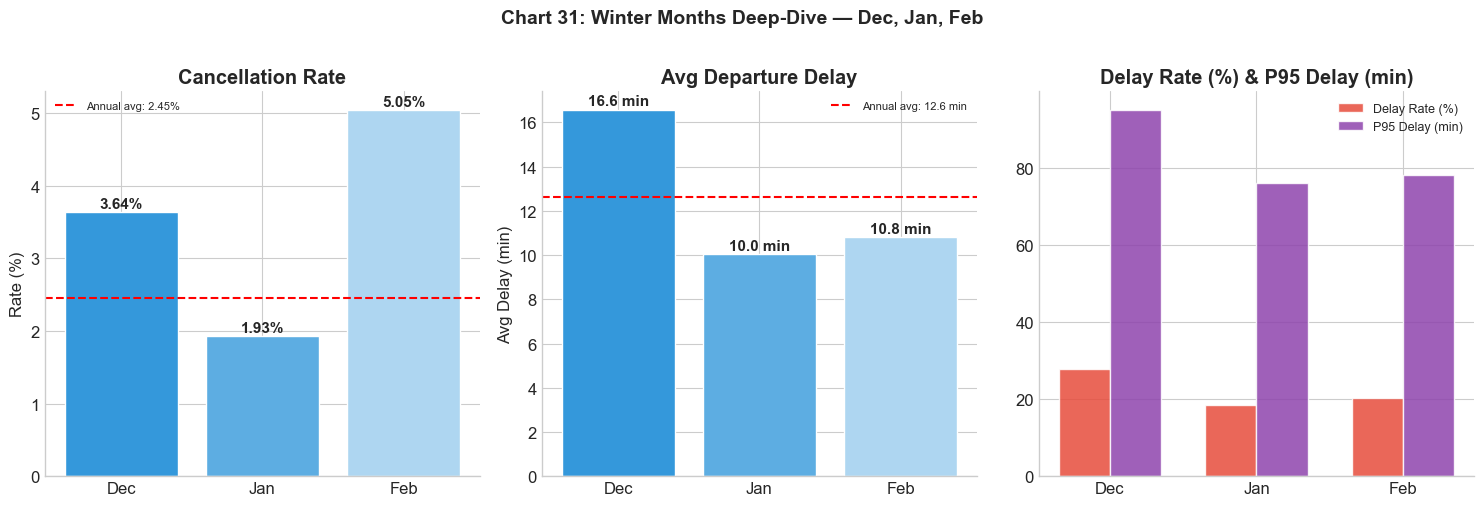

Chart 31 saved.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
winter_colors = ['#3498db','#5dade2','#aed6f1']

# Cancellation rate
bars = axes[0].bar(winter_df['month'], winter_df['cancel_rate'],
                   color=winter_colors, edgecolor='white')
axes[0].axhline(baseline_cancel, color='red', linestyle='--',
                linewidth=1.5, label=f'Annual avg: {baseline_cancel:.2f}%')
for bar, val in zip(bars, winter_df['cancel_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Cancellation Rate', fontweight='bold')
axes[0].set_ylabel('Rate (%)')
axes[0].legend(fontsize=8)

# Avg delay
bars2 = axes[1].bar(winter_df['month'], winter_df['avg_delay'],
                    color=winter_colors, edgecolor='white')
axes[1].axhline(baseline_delay, color='red', linestyle='--',
                linewidth=1.5, label=f'Annual avg: {baseline_delay:.1f} min')
for bar, val in zip(bars2, winter_df['avg_delay']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f} min', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Avg Departure Delay', fontweight='bold')
axes[1].set_ylabel('Avg Delay (min)')
axes[1].legend(fontsize=8)

# Delay rate + P95
x = np.arange(3)
w = 0.35
axes[2].bar(x - w/2, winter_df['delay_rate'], w, label='Delay Rate (%)',  color='#e74c3c', edgecolor='white', alpha=0.85)
axes[2].bar(x + w/2, winter_df['p95_delay'],  w, label='P95 Delay (min)', color='#8e44ad', edgecolor='white', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(winter_df['month'])
axes[2].set_title('Delay Rate (%) & P95 Delay (min)', fontweight='bold')
axes[2].legend(fontsize=9)

fig.suptitle('Chart 31: Winter Months Deep-Dive — Dec, Jan, Feb',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart31_winter_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 31 saved.')

---
## Chart 32: Seasonal Violin Plot of Departure Delay

The violin plot captures the full **distribution shape** (not just averages), revealing whether
delay distributions are heavy-tailed in certain seasons.

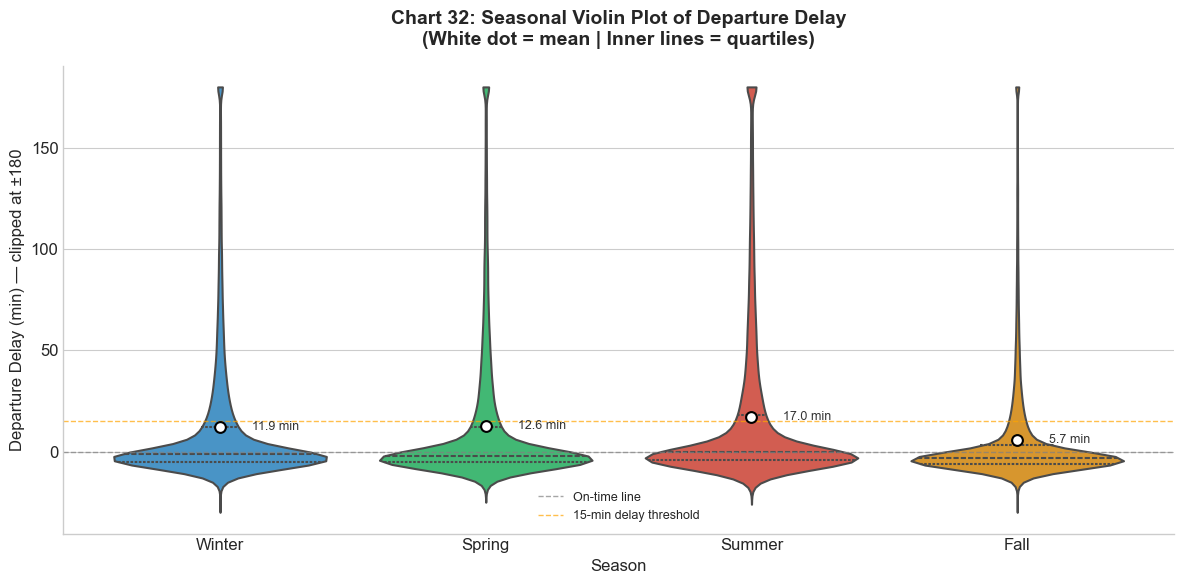

Chart 32 saved.


In [11]:
# Clip extreme outliers for visualization
violin_data = df_completed.copy()
violin_data['dep_delay_clipped'] = violin_data['dep_delay'].clip(-30, 180)
violin_data['season'] = pd.Categorical(violin_data['season'], categories=SEASON_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(
    data=violin_data, x='season', y='dep_delay_clipped',
    order=SEASON_ORDER,
    palette=SEASON_COLORS,
    inner='quartile',
    cut=0,
    linewidth=1.5,
    ax=ax
)

# Add mean markers
season_means = violin_data.groupby('season')['dep_delay_clipped'].mean().reindex(SEASON_ORDER)
for i, (season, mean_val) in enumerate(season_means.items()):
    ax.scatter(i, mean_val, color='white', s=60, zorder=5, edgecolors='black', linewidth=1.5)
    ax.text(i + 0.12, mean_val, f'{mean_val:.1f} min', va='center', fontsize=9, color='#333')

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='On-time line')
ax.axhline(15, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='15-min delay threshold')
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Departure Delay (min) — clipped at ±180', fontsize=12)
ax.set_title('Chart 32: Seasonal Violin Plot of Departure Delay\n(White dot = mean | Inner lines = quartiles)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart32_seasonal_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 32 saved.')

---
## 3. Key Findings — Seasonal & Cancellation Analysis

In [12]:
worst_cancel_month = monthly['cancel_rate'].idxmax()
worst_cancel_day   = daily_cancel['cancel_rate'].idxmax()
mname = MONTH_NAMES[int(monthly.loc[worst_cancel_month,'month'])-1]
dname = daily_cancel.loc[worst_cancel_day,'day_name']

holiday_worst = holiday_df_summary.loc[holiday_df_summary['delay_vs_baseline'].idxmax(), 'holiday'].split('(')[0].strip()

print('=== KEY FINDINGS: Seasonal & Cancellation Analysis ===')
print(f"""
► Overall cancellation rate : {overall_cancel:.2f}% of all flights
► Worst cancellation month  : {mname} ({monthly.loc[worst_cancel_month,'cancel_rate']:.2f}% cancel rate)
► Worst cancellation day    : {dname} ({daily_cancel.loc[worst_cancel_day,'cancel_rate']:.2f}% cancel rate)
► Winter months (Dec–Feb) show the highest combo of delays AND cancellations
► Holiday season with biggest delay impact: {holiday_worst}
► Proxy analysis suggests weather is the dominant inferred cancellation cause
  in January, February, and July (storm season)
► Carrier-attributed cancellations peak in months with low weather burden,
  pointing to airline operational inefficiencies
► Summer shows the widest violin distribution — more extreme outlier delays
  while winter shows a higher share of severe/extreme categories
""")

=== KEY FINDINGS: Seasonal & Cancellation Analysis ===

► Overall cancellation rate : 2.45% of all flights
► Worst cancellation month  : Feb (5.05% cancel rate)
► Worst cancellation day    : Friday (3.20% cancel rate)
► Winter months (Dec–Feb) show the highest combo of delays AND cancellations
► Holiday season with biggest delay impact: July 4th Week
► Proxy analysis suggests weather is the dominant inferred cancellation cause
  in January, February, and July (storm season)
► Carrier-attributed cancellations peak in months with low weather burden,
  pointing to airline operational inefficiencies
► Summer shows the widest violin distribution — more extreme outlier delays
  while winter shows a higher share of severe/extreme categories



---
*End of Week 6 — Seasonal & Cancellation Analysis*  
Charts saved to `outputs/figures/`.  